# 08. Advanced Visualization Types
## 📚 Learning Objectives

By completing this notebook, you will:
- Create advanced visualization types (violin plots, heatmaps, pair plots)
- Understand when to use each visualization type
- Combine multiple visualizations for comprehensive analysis
- Customize advanced plots for presentations

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 3, lesson 03 "Seaborn Statistical Plots" — violin, pair and heatmap plots are the statistical end of the same library.

**Used later in:** Course 05 — Unit 4, lesson 07, whose confusion matrices are heatmaps, and Course 12 (AIAT 126) — Unit 4.

---


## 🎯 The case: Florence Nightingale invents a chart to win an argument

Nightingale returned from the Crimean War in 1856 convinced of something the British Army
did not want to hear: its soldiers were dying overwhelmingly of **preventable disease** —
typhus, typhoid, cholera, dysentery — and not of battle wounds. In her first winter at
Scutari alone, **4,077 British soldiers died**, roughly ten times as many from illness as
from wounds.

She had the statistics. Statistics had not worked. So in 1858 she drew what she called a
**coxcomb** — a polar-area diagram in which each month is a wedge and the area shows the
deaths, split by cause — and put it in front of Members of Parliament and civil servants
who, as she put it, would never read a statistical table. In **1859 she became the first
woman elected to the Royal Statistical Society**, and an honorary member of the American
Statistical Association in 1874.

She did not invent a new chart because the old ones were ugly. She invented one because the
existing charts could not hold *time*, *magnitude* and *cause* at once, and her argument
needed all three.

**What goes wrong without this lesson.** That is exactly what "advanced" chart types are
for — not sophistication, but showing more than two things at once. Below, a box plot of
passenger age by class would give you three medians (**37, 29, 24**). The **violin** gives
you the shapes behind them, and the shapes are the finding: third class is the youngest
*and* the most spread out, first class bulges in middle age. Same three groups, more
argument.


## The Story

**BEFORE**: You know basic visualization but don't know advanced techniques for complex data.

**AFTER**: You'll learn advanced visualization: multi-panel plots, 3D visualizations, and specialized chart types!

**Why this matters**: Advanced Visualization Types is essential for building complete, professional data science solutions!

---

**All concepts are explained in the code comments below - you can learn everything from this notebook alone!**

---

## 🔗 Beyond Basic Charts

**You know basic charts, but what about advanced ones?**
- We've learned line, bar, scatter plots
- But there are more powerful visualization types!
- Advanced plots reveal deeper insights

**This notebook teaches advanced visualizations!**
- We'll learn **violin plots** - distribution + density
- We'll learn **heatmaps** - correlation and patterns
- We'll learn **pair plots** - multi-variable relationships
- We'll learn **facet grids** - multi-panel comparisons

**This unlocks professional data visualization!**

---

## Learning Objectives
1. Create violin plots for distribution comparison
2. Build heatmaps for correlation analysis
3. Generate pair plots for multi-variable exploration
4. Use facet grids for comparative analysis

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `titanic.csv` — the 891-passenger manifest of the RMS Titanic.
  Real columns (`Age`, `Fare`, `Pclass`, `Sex`, `SibSp`, `Parch`, `Survived`),
  real gaps (177 ages are missing) and real skew (fares run from £0 to £512).
- matplotlib, seaborn, pandas

**Outputs:** What you'll see when you run the cells

- Violin, heatmap, pair plot and facet grid, each reading the same real manifest
- Printed statistics behind every figure, so you can check the chart against the numbers

---


In [1]:
# WHAT: Import libraries and preview the four advanced chart types.
# WHY: Violin, heatmap, pair plot, and facet grid each solve a comparison problem basic charts handle poorly.

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported!")
print("\n📚 This notebook covers:")
print("   - Violin plots")
print("   - Heatmaps")
print("   - Pair plots")
print("   - Facet grids")

✅ Libraries imported!

📚 This notebook covers:
   - Violin plots
   - Heatmaps
   - Pair plots
   - Facet grids


In [2]:
# WHAT: Load the real Titanic manifest - the dataset every chart below reads.
# WHY: Real passenger data has genuinely different group distributions (class, sex, age),
#      so the advanced charts reveal something true instead of something we planted.

# Step 2: Load real data
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
df = load("titanic")

# A readable class label for the category axis (1st/2nd/3rd class cabins)
df['Class'] = df['Pclass'].map({1: '1st class', 2: '2nd class', 3: '3rd class'})

print(f"Dataset shape: {df.shape}")
print(f"Missing values (real gaps, nothing removed): "
      f"{df[['Age', 'Fare', 'Embarked']].isna().sum().to_dict()}")
print(f"\nAge by class (median):\n{df.groupby('Class')['Age'].median().to_string()}")
print(f"\nFare by class (median):\n{df.groupby('Class')['Fare'].median().to_string()}")
print(f"\nFirst 5 rows:")
print(df[['Class', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch', 'Survived']].head())

titanic: full file, 891 rows.
Dataset shape: (891, 13)
Missing values (real gaps, nothing removed): {'Age': 177, 'Fare': 0, 'Embarked': 2}

Age by class (median):
Class
1st class    37.0
2nd class    29.0
3rd class    24.0

Fare by class (median):
Class
1st class    60.2875
2nd class    14.2500
3rd class     8.0500

First 5 rows:
       Class     Sex   Age     Fare  SibSp  Parch  Survived
0  3rd class    male  22.0   7.2500      1      0         0
1  1st class  female  38.0  71.2833      1      0         1
2  3rd class  female  26.0   7.9250      0      0         1
3  1st class  female  35.0  53.1000      1      0         1
4  3rd class    male  35.0   8.0500      0      0         0


Violin Plot

💡 Violin plots show distribution + density


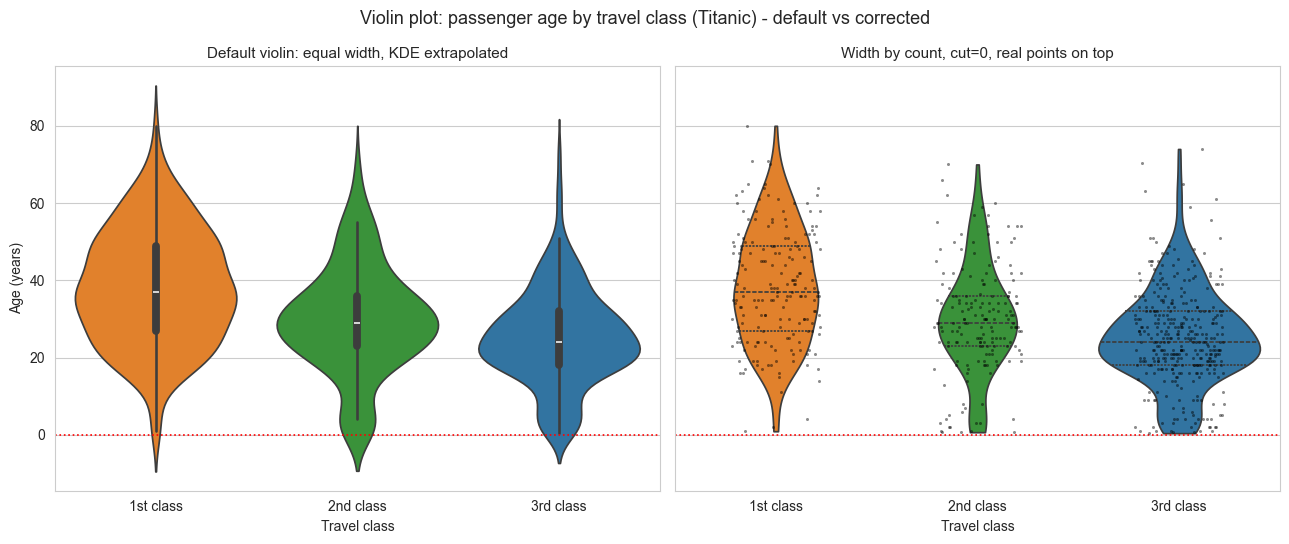


✅ Violin plot created!
           count  mean   50%   std
Class                             
1st class  186.0  38.2  37.0  14.8
2nd class  173.0  29.9  29.0  14.0
3rd class  355.0  25.1  24.0  12.5

Read it: third class is the youngest and the widest spread; first class
bulges around middle age. The counts differ because 177 ages are missing.

Passengers under 13 by class: {'1st class': 4, '2nd class': 17, '3rd class': 48} - the dots in the right
panel are those children; the left panel smooths them into the curve.
The youngest passenger on board was 0.42 years old; the LEFT panel's curves still run below zero, which no passenger can be.


In [3]:
# WHAT: Draw the violin plot twice - seaborn's default, then the same ages with the two
#       corrections a careful analyst makes: width scaled by group size, and the real points on top.
# WHY: A violin is a box plot plus a KDE, and a KDE is a smoothing CHOICE. Seeing both versions
#      side by side shows exactly what the default is hiding.

# Step 3: Violin Plot
print("=" * 70)
print("Violin Plot")
print("=" * 70)
print("\n💡 Violin plots show distribution + density")

ORDER = ['1st class', '2nd class', '3rd class']
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

# LEFT: the default. Every violin gets the same maximum width, and the KDE is
# extrapolated past the smallest and largest observed age.
sns.violinplot(data=df, x='Class', y='Age', hue='Class', legend=False,
               order=ORDER, ax=axes[0])
axes[0].set_title('Default violin: equal width, KDE extrapolated', fontsize=11)

# RIGHT: three corrections, each one line.
#   density_norm='count' + common_norm=True -> width now carries the group size
#   cut=0                                   -> the curve stops at the real min/max age
#   stripplot on top                        -> the actual observations, not just their smooth
sns.violinplot(data=df, x='Class', y='Age', hue='Class', legend=False, order=ORDER,
               ax=axes[1], density_norm='count', common_norm=True,
               inner='quartile', cut=0)
sns.stripplot(data=df, x='Class', y='Age', order=ORDER, ax=axes[1],
              color='black', size=2.2, alpha=0.45, jitter=0.22)
axes[1].set_title("Width by count, cut=0, real points on top", fontsize=11)

for ax in axes:
    ax.set_xlabel('Travel class')
    ax.set_ylabel('Age (years)')
axes[0].axhline(0, color='red', linestyle=':', linewidth=1.2)
axes[1].axhline(0, color='red', linestyle=':', linewidth=1.2)
fig.suptitle('Violin plot: passenger age by travel class (Titanic) - default vs corrected',
             fontsize=13)
plt.tight_layout()
plt.show()
print("\n✅ Violin plot created!")
print(df.groupby('Class')['Age'].describe()[['count', 'mean', '50%', 'std']].round(1).to_string())
print("\nRead it: third class is the youngest and the widest spread; first class")
print("bulges around middle age. The counts differ because 177 ages are missing.")
youngest = df[df['Age'] < 13].groupby('Class')['Age'].count()
print(f"\nPassengers under 13 by class: {youngest.to_dict()} - the dots in the right")
print("panel are those children; the left panel smooths them into the curve.")
print(f"The youngest passenger on board was {df['Age'].min():.2f} years old;"
      " the LEFT panel's curves still run below zero, which no passenger can be.")


**Read the figure.** Same 714 ages, same three classes, two sets of defaults. On the
**left**, seaborn's out-of-the-box violin: all three shapes are drawn to the same maximum
width even though 1st class contributes **186** usable ages and 3rd class **355**, and each
curve is extrapolated past the youngest passenger — every violin crosses the red zero line
into negative ages. On the **right**, three one-line corrections: width now scales with the
group size, so 3rd class is the bulkiest shape on the panel; `cut=0` stops each curve at the
real minimum and maximum, so nothing dips below zero; and the black dots are the actual
passengers, including the **48 third-class children under 13** whose cluster near the floor
the smooth curve had rendered as a gentle bulge.

The lesson is not "always use the right-hand version". It is that a violin is a *model* of
your data, and the default settings of that model were chosen by someone who had never seen
your data.



Heatmap

💡 Heatmaps show correlations and patterns


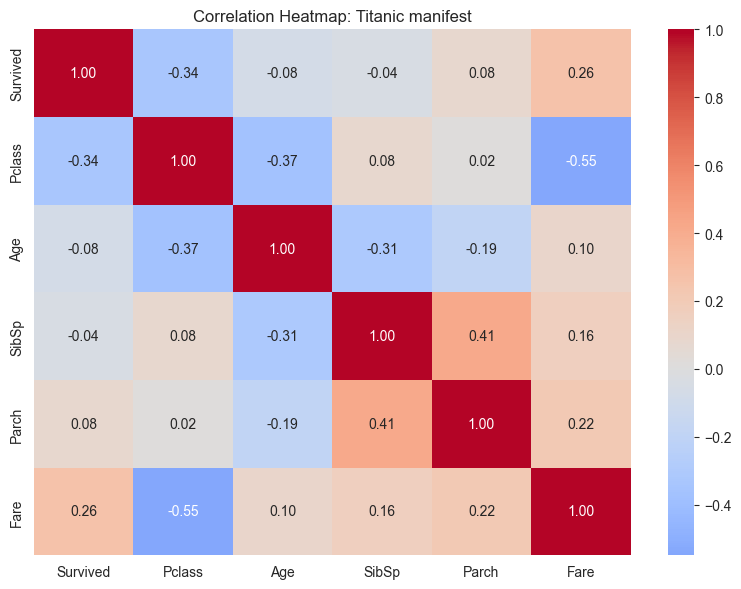


✅ Heatmap created!
          Survived  Pclass   Age  SibSp  Parch  Fare
Survived      1.00   -0.34 -0.08  -0.04   0.08  0.26
Pclass       -0.34    1.00 -0.37   0.08   0.02 -0.55
Age          -0.08   -0.37  1.00  -0.31  -0.19  0.10
SibSp        -0.04    0.08 -0.31   1.00   0.41  0.16
Parch         0.08    0.02 -0.19   0.41   1.00  0.22
Fare          0.26   -0.55  0.10   0.16   0.22  1.00

Strongest pair with survival: Pclass (-0.34) - a NEGATIVE number because
class 1 is the most expensive: lower class number, higher survival.


In [4]:
# WHAT: Draw a correlation heatmap of the manifest's numeric columns.
# WHY: Color-coding correlations lets you scan many relationships at once.

# Step 4: Heatmap
print("\n" + "=" * 70)
print("Heatmap")
print("=" * 70)
print("\n💡 Heatmaps show correlations and patterns")

numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
correlation = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap: Titanic manifest')
plt.tight_layout()
plt.show()
print("\n✅ Heatmap created!")
print(correlation.round(2).to_string())
print(f"\nStrongest pair with survival: Pclass "
      f"({correlation.loc['Survived', 'Pclass']:.2f}) - a NEGATIVE number because")
print("class 1 is the most expensive: lower class number, higher survival.")


Pair Plot

💡 Pair plots show relationships between all variables
Rows plotted: 714 of 891 (177 dropped for missing Age)


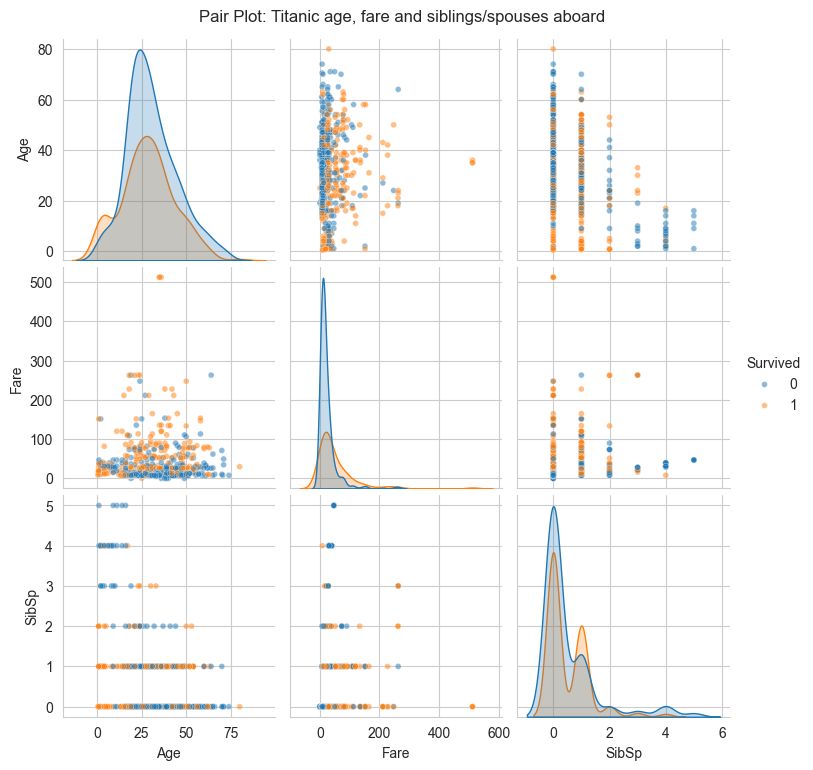


✅ Pair plot created!


In [5]:
# WHAT: Draw a pair plot with KDE diagonals, coloured by survival.
# WHY: One command inspects every scatter pair and every distribution - the quickest multivariate overview.

# Step 5: Pair Plot
print("\n" + "=" * 70)
print("Pair Plot")
print("=" * 70)
print("\n💡 Pair plots show relationships between all variables")

# Pair plots cannot draw NaNs, so we drop the rows with a missing age
# and SAY how many that was - silently losing rows is how charts start lying.
pair_df = df[['Age', 'Fare', 'SibSp', 'Survived']].dropna()
print(f"Rows plotted: {len(pair_df)} of {len(df)} "
      f"({len(df) - len(pair_df)} dropped for missing Age)")

sns.pairplot(pair_df, hue='Survived', diag_kind='kde',
             plot_kws={'alpha': 0.5, 's': 18})
plt.suptitle('Pair Plot: Titanic age, fare and siblings/spouses aboard', y=1.02)
plt.show()
print("\n✅ Pair plot created!")

## 💬 Discuss

The pair plot printed a line worth stopping on: **"Rows plotted: 714 of 891 (177 dropped
for missing Age)"**. Meanwhile the violin shows 1st class n=186, 2nd n=173, 3rd n=355 —
also after dropping.

1. Twenty percent of the manifest silently vanished from the pair plot, and Unit 2 lesson
   02 established that missing ages are **not** missing at random. So what population does
   that pair plot actually describe? Write the caption that says so honestly.
2. Median fare by class is **£60.29 / £14.25 / £8.05** and median age is **37 / 29 / 24**.
   A colleague concludes "older passengers paid more". Using the heatmap value **Age vs
   Fare r = 0.10**, explain why that conclusion does not follow — and name the statistical
   trap it is an example of.
3. Nightingale invented a chart type because none existed for her argument. Look at the
   four chart types in this notebook and pick the one you would drop from the curriculum.
   Defend the cut: what question does it answer that another chart here does not answer
   better?



Facet Grids

💡 Facet grids repeat the same plot once per subgroup - ideal for comparisons


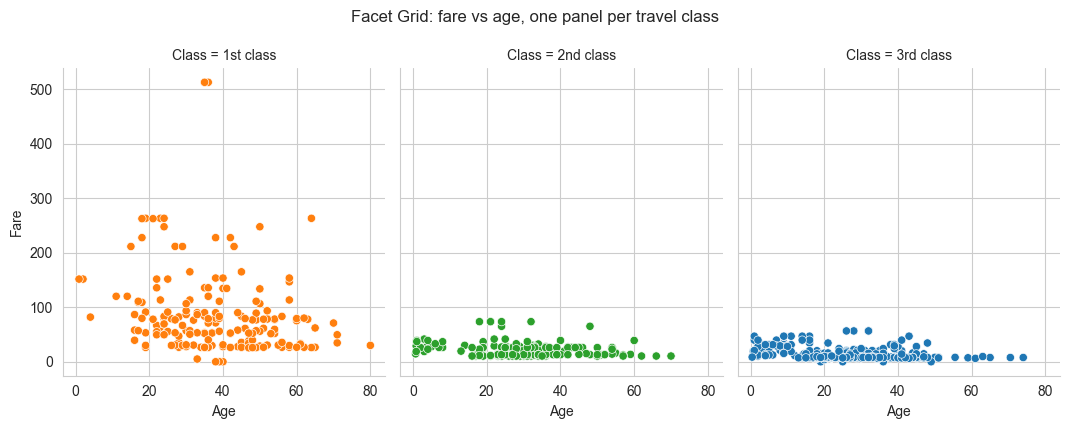

✅ Facet grid created - one scatter panel per travel class!
Shared axes make the point immediately: the fare range in 1st class dwarfs
the other two, and the £512 outliers all sit in the 1st-class panel.

Summary

✅ Advanced visualization types, all read from the real 891-passenger Titanic manifest:
   1. Violin plot  - age distribution + density per travel class
   2. Heatmap      - correlations at a glance (Pclass vs Survived: -0.34)
   3. Pair plot    - all pairwise relationships, coloured by survival
   4. Facet grid   - fare vs age repeated per class

🎯 When to reach for them:
   - Compare distributions across groups → violin
   - Scan many correlations           → heatmap
   - Explore a new dataset            → pair plot
   - Same question, many subgroups    → facet grid

⚠️  Real data has gaps: 177 of 891 ages are missing. Charts that
   silently drop those rows change the story - always report what you dropped.

✅ Advanced visualization types - complete!


In [6]:
# WHAT: Draw a facet grid - one age-vs-fare panel per travel class - then summarize.
# WHY: Small multiples keep axes identical across panels, making between-group comparison fair.

# Step 6: Facet Grids
print("\n" + "=" * 70)
print("Facet Grids")
print("=" * 70)
print("\n💡 Facet grids repeat the same plot once per subgroup - ideal for comparisons")

g = sns.relplot(data=df, x='Age', y='Fare', col='Class',
                col_order=['1st class', '2nd class', '3rd class'],
                hue='Class', height=4, aspect=0.9, legend=False)
g.figure.suptitle('Facet Grid: fare vs age, one panel per travel class', y=1.06)
plt.show()
print("✅ Facet grid created - one scatter panel per travel class!")
print("Shared axes make the point immediately: the fare range in 1st class dwarfs")
print("the other two, and the £512 outliers all sit in the 1st-class panel.")

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"""
✅ Advanced visualization types, all read from the real {len(df)}-passenger Titanic manifest:
   1. Violin plot  - age distribution + density per travel class
   2. Heatmap      - correlations at a glance (Pclass vs Survived: {correlation.loc['Survived', 'Pclass']:.2f})
   3. Pair plot    - all pairwise relationships, coloured by survival
   4. Facet grid   - fare vs age repeated per class

🎯 When to reach for them:
   - Compare distributions across groups → violin
   - Scan many correlations           → heatmap
   - Explore a new dataset            → pair plot
   - Same question, many subgroups    → facet grid

⚠️  Real data has gaps: {df['Age'].isna().sum()} of {len(df)} ages are missing. Charts that
   silently drop those rows change the story - always report what you dropped.
""")
print("✅ Advanced visualization types - complete!")

## ⚠️ Where this breaks

- **Violin plots are KDEs in disguise, and a KDE is a smoothing choice.** The bandwidth is
  estimated, and the curve will place density where no observation exists — a violin of
  `Age` extends below zero years. It also invites reading a bimodal bump that is an artefact
  of the bandwidth. Overlay the actual points (`stripplot`, `swarmplot`) when the group is
  small enough to draw them.
- **Pair plots drop rows without asking.** 177 of 891 passengers disappeared here because
  their age is missing, and the notebook is unusual in saying so out loud. Most pair plots
  in most reports do not.
- **Correlation heatmaps of mixed variable types are misleading by construction.**
  `Pclass` is ordinal, `Survived` is binary, `Fare` is continuous and skewed. Pearson's r
  between a binary and a skewed continuous variable is defined but not interpretable the
  way the colour scale implies. The **−0.55** between Fare and Pclass mostly says the two
  columns measure the same thing.
- **The assumption that must hold: the groups you are comparing are comparable.** First
  class has 186 usable ages, third class 355. Seaborn's DEFAULT violins — the left panel
  above — are drawn to the same width regardless, giving equal visual weight to unequal
  evidence. Use `density_norm='count'` with `common_norm=True` (seaborn 0.13+; `scale='count'`
  in older versions), as the right-hand panel does, when the group sizes differ and it
  matters.
- **These charts do not scale.** A pair plot is O(n²) panels in columns and O(n) points in
  rows. On the 663,522-row 911 log it is unusable, and on 40 columns it is unreadable
  regardless of row count.
- **Cheaper alternative:** if you are comparing three groups on one variable, an
  overlaid histogram or an ECDF plot is easier to read than a violin and makes no smoothing
  assumption. Reach for violins when the *shape* is the point and you have enough
  observations per group — a few hundred, not a few dozen — to justify one.


## 📚 References

1. Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
2. Wickham, H. (2010). *A Layered Grammar of Graphics*. Journal of Computational and Graphical Statistics, 19(1), 3-28. <https://doi.org/10.1198/jcgs.2009.07098>
3. Waskom, M. L. (2021). *seaborn: Statistical Data Visualization*. Journal of Open Source Software, 6(60), 3021. <https://joss.theoj.org/papers/10.21105/joss.03021>
4. Chen, N., Zhang, Y., Xu, J., Ren, K., & Yang, Y. (2024). *VisEval: A Benchmark for Data Visualization in the Era of Large Language Models*. arXiv:2407.00981. <https://arxiv.org/abs/2407.00981>
5. Xie, Y., Zhang, Z., Wu, Y., et al. (2025). *VisJudge-Bench: Aesthetics and Quality Assessment of Visualizations*. arXiv:2510.22373. <https://arxiv.org/abs/2510.22373>
